# Exercice 3

Vous avez un dataset de critiques de films (positives et negatives). Creez un vectoriseur TF-IDF et entrainez un classifieur Logistic Regression.

Etapes :

1. Charger et nettoyer les donnees
2. Vectoriser avec TfidfVectorizer (parametres optimaux)
3. Diviser train/test
4. Entraizer LogisticRegression
5. Evaluer (accuracy, precision, recall)

In [231]:
reviews = [
    "Ce film est genial et passionnant!",
    "Horrible, une perte de temps",
    "Excellent! A regarder absolument",
    "Nul et ennuyeux au maximum",
    "Un chef-d'oeuvre absolu, j'ai adore chaque minute",
    "Decevant et mal realise, je ne recommande pas",
    "Incroyable! Les acteurs sont formidables",
    "Catastrophique, le scenario est ridicule",
    "Brillant et emouvant, une vraie reussite",
    "Tres mauvais, j'ai failli partir avant la fin",
    "Superbe film, plein d'emotion et de suspense",
    "Nul a pleurer, quelle deception",
    "Magnifique cinematographie et excellente histoire",
    "Affreux, le pire film que j'ai vu cette annee",
    "Fantastique! Une experience inoubliable",
    "Tres ennuyeux, je me suis endormi",
    "Parfait du debut a la fin",
    "Lamentable, un vrai desastre",
    "J'ai passe un excellent moment, tres divertissant",
    "Mediocre et sans interet",
    "Une perle rare du cinema francais",
    "Horrible execution, aucun interet",
    "Captivant et bien ecrit",
    "Pathétique, une insulte au cinema",
    "Remarquable performance des acteurs",
    "Totalement rate, quelle perte d'argent",
    "Splendide et touchant",
    "Navrant et mal joue",
    "Un pur moment de bonheur",
    "Extremement decevant et fade",
    "Merveilleux, je le recommande vivement",
    "Atroce, je n'ai pas accroche du tout",
    "Eblouissant de bout en bout",
    "Tres mauvais gout et mal ficele",
    "Grandiose et memorable",
    "Consternant de nullite",
    "Fascinant et original",
    "Barbant et sans saveur",
    "Exceptionnel, un must-see",
    "Epouvantable, a eviter absolument",
    "Tres agreable a regarder",
    "Nullissime et pretentieux",
    "Formidable histoire et beaux dialogues",
    "Desastreux et mal monte",
    "Sublime realisation",
    "Insupportable d'ennui",
    "Tres bon film, bien rythme",
    "Completement rate",
    "Enchanteur et poetique",
    "Penible a regarder",
    "Vraiment excellent travail",
    "Mediocre au possible",
    "Tres reussi et coherent",
    "Mauvais sur tous les plans",
    "Superbe surprise cinematographique",
    "Lamentable interpretation",
    "Admirable et bien construit",
    "Navrant de platitude",
    "Tres beau film d'auteur",
    "Catastrophe totale",
    "Magnifiquement realise et joue",
    "Horrible du debut a la fin",
    "Excellente mise en scene",
    "Nul et sans imagination",
    "Passionnant et bien ficelé",
    "Tres decevant, sans interet",
    "Formidable experience cinematographique",
    "Affreusement mauvais",
    "Remarquable et intense",
    "Penible et ennuyeux",
    "Tres plaisant a regarder",
    "Completement nul",
    "Belle histoire et bon jeu d'acteur",
    "Desastreux scenario",
    "Captivant du debut a la fin",
    "Horrible gachis",
    "Tres bien realise",
    "Mauvais et sans interet",
    "Excellent divertissement",
    "Lamentable sur tous les plans",
    "Magnifique oeuvre cinematographique",
    "Pathétique et mal ecrit",
    "Vraiment genial",
    "Totalement rate",
    "Superbe et touchant",
    "Affreux et mal joue",
    "Tres bon moment passe",
    "Nul et pretentieux",
    "Remarquable qualite",
    "Horrible deception",
    "Excellente surprise",
    "Tres mauvais film",
    "Magnifique et emouvant",
    "Desastreux et ennuyeux",
    "Formidable et captivant",
    "Lamentable et fade",
    "Tres reussi",
    "Completement mauvais",
    "Belle reussite",
    "Catastrophique",
]
y = [
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
]


In [232]:
from typing import Callable
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    silhouette_score,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

nlp = spacy.load("fr_core_news_sm")


def ensure_stopwords_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


def ensure_wordnet_downloaded():
    try:
        nltk.data.find("corpora/wordnet")
    except LookupError:
        nltk.download("wordnet")


ensure_stopwords_downloaded()
ensure_wordnet_downloaded()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [233]:
class TextCleaner:
    def __init__(self, sentences: list[str]):
        self.sentences = sentences
        self.sentences_cleaned = []
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        self.punctuations = string.punctuation
        self.stop_words = stopwords.words("french")

    def to_lower(self, sentence: str) -> str:
        return sentence.lower()

    def remove_punctuations(self, sentence: str) -> str:
        return re.sub(f"[{re.escape(self.punctuations)}]", " ", sentence)

    def remove_useless_spaces(self, sentence: str) -> str:
        return re.sub(r"\s{2,}", " ", sentence).strip()

    def tokenize_sentence(self, sentence: str) -> list[str]:
        return sentence.split(" ")

    def remove_stop_words(self, tokens: list[str]) -> list[str]:
        return [token for token in tokens if token not in self.stop_words]

    def lemmatization_nltk(self, tokens: list[str]) -> list[str]:
        return [self.lemmatizer.lemmatize(token) for token in tokens]

    def lemmatization_spacy(self, tokens: list[str]) -> list[str]:
        doc = nlp(" ".join(tokens))
        return [token.lemma_ for token in doc]

    def stemming(self, tokens: list[str]) -> list[str]:
        return [self.stemmer.stem(token) for token in tokens]

    def to_str(self, tokens: list[str]) -> str:
        return " ".join(tokens)

    def process_cleaning(self, sentence: str, transformers: list[Callable]) -> str:
        for transformer in transformers:
            sentence = transformer(sentence)
        return sentence

    def clean(self) -> list[str]:
        for sentence in self.sentences:
            self.sentences_cleaned.append(
                self.process_cleaning(
                    sentence=sentence,
                    transformers=[
                        self.to_lower,
                        self.remove_punctuations,
                        self.remove_useless_spaces,
                        self.tokenize_sentence,
                        self.remove_stop_words,
                        self.lemmatization_nltk,
                        self.to_str,
                    ],
                )
            )
        return


text_cleaner = TextCleaner(sentences=reviews)
text_cleaner.clean()
print(text_cleaner.sentences_cleaned[:3])

['film genial passionnant', 'horrible perte temp', 'excellent a regarder absolument']


In [234]:
vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=1,
    max_df=0.9,
    ngram_range=(1, 2),
)

X = vectorizer.fit_transform(text_cleaner.sentences_cleaned)

features = vectorizer.get_feature_names_out()
print(f"Vocabulaire : {len(features)} mots")
print(f"10 premiers mots : {features[:10]}")

Vocabulaire : 200 mots
10 premiers mots : ['absolument' 'accroche' 'accroche tout' 'acteur' 'acteurs'
 'acteurs formidables' 'admirable' 'admirable bien' 'adore' 'adore chaque']


In [235]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Dimensions jeu d'entraînement : {X_train.shape}")
print(f"Dimensions jeu de test : {X_test.shape}")
print(f"Proportion de 1 de les labels d'entraînement : {sum(y_train) / len(y_train)}")
print(f"Proportion de 1 de les labels de test : {sum(y_test) / len(y_test)}")

Dimensions jeu d'entraînement : (80, 200)
Dimensions jeu de test : (20, 200)
Proportion de 1 de les labels d'entraînement : 0.5
Proportion de 1 de les labels de test : 0.5


In [236]:
lr = LogisticRegression(random_state=42)

lr_fitted = lr.fit(X_train, y_train)

In [237]:
y_pred = lr_fitted.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



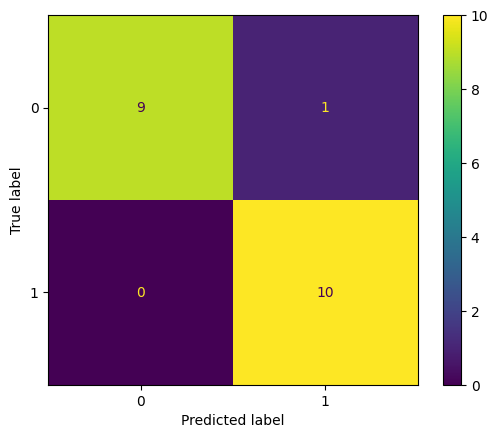

In [238]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

In [239]:
coefficients = lr.coef_[0]
feature_importance = pd.DataFrame({"feature": features, "importance": coefficients})
feature_importance["abs_importance"] = np.abs(feature_importance["importance"])
feature_importance = feature_importance.sort_values(
    by="abs_importance", ascending=False
)

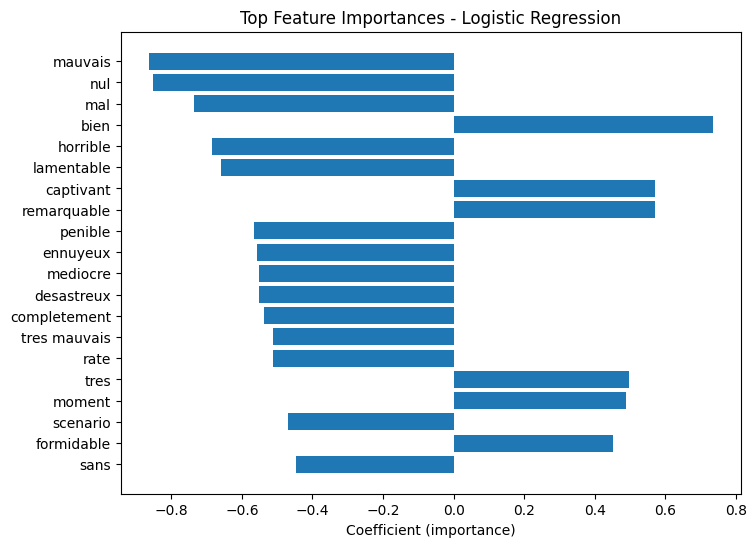

In [240]:
top_features = feature_importance.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Coefficient (importance)")
plt.title("Top Feature Importances - Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

In [246]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_train)

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(variance_cumulee >= 0.90) + 1
print("Nombre optimal de composantes :", n_components)

Nombre optimal de composantes : 57


In [247]:
pca_optimal = PCA(n_components=n_components, random_state=42)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

In [248]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10, init="k-means++")
y_pred_kmeans = kmeans.fit_predict(X_pca_optimal)

print(f"Inertie (variance intra-cluster) : {kmeans.inertia_:.2f}")
print(f"Nombre d'itérations : {kmeans.n_iter_}")
print(f"Silhouette score : {silhouette_score(X_train, y_pred_kmeans)}")

Inertie (variance intra-cluster) : 12105.87
Nombre d'itérations : 2
Silhouette score : 0.011243579445358174


In [249]:
unique, counts = np.unique(y_pred_kmeans, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(
        f"Cluster {cluster_id}: {count} points ({count / len(y_pred_kmeans) * 100:.1f}%)"
    )

Cluster 0: 79 points (98.8%)
Cluster 1: 1 points (1.2%)


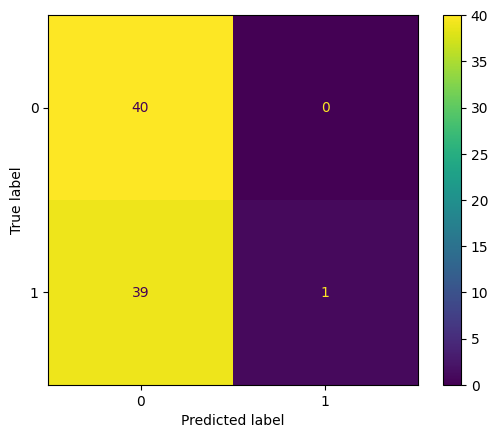

In [250]:
cm_kmeans = confusion_matrix(y_train, y_pred_kmeans)

ConfusionMatrixDisplay(cm_kmeans).plot()

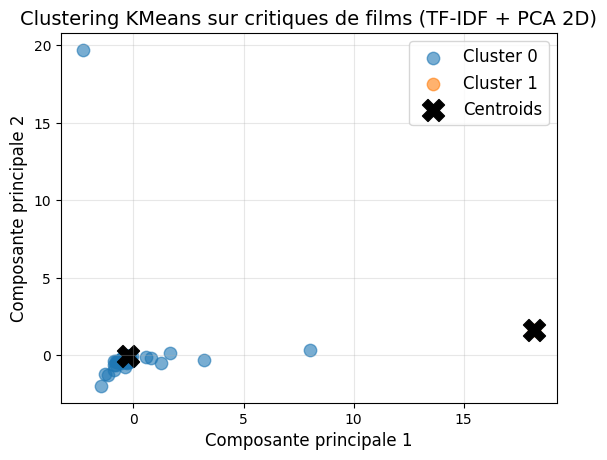

In [251]:
colors = ["#1f77b4", "#ff7f0e"]
for cluster in range(2):
    plt.scatter(
        X_pca[y_pred_kmeans == cluster, 0],
        X_pca[y_pred_kmeans == cluster, 1],
        s=80,
        alpha=0.6,
        label=f"Cluster {cluster}",
        color=colors[cluster],
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c="black",
    marker="X",
    label="Centroids",
)

plt.title("Clustering KMeans sur critiques de films (TF-IDF + PCA 2D)", fontsize=14)
plt.xlabel("Composante principale 1", fontsize=12)
plt.ylabel("Composante principale 2", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()